
=== XNOR Gate using Multi-Layer Perceptron ===
Hidden Layer Weights:
 [[ 2.9042543   2.01908142  2.52400853  2.97074942 -4.02045214 -3.6891038 ]
 [-4.03175588  2.06139053  2.42290408  3.01421264 -4.0008943   2.48308798]
 [ 3.25618818  1.42306793 -3.47546552 -3.75099474 -4.09120348  2.82107979]]
Output Layer Weights:
 [[-4.03224581]
 [ 3.3050268 ]
 [-2.73589878]
 [-2.22122157]
 [ 1.26700439]
 [-4.01855098]]
Biases:
 [array([-1.01122878, -2.56331273, -0.57809079, -0.97040664,  1.03013401,
       -0.75559232]), array([0.94027259])]

Predictions: [1 0 0 1 0 1 1 0]

Accuracy: 1.0

Confusion Matrix:
 [[4 0]
 [0 4]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



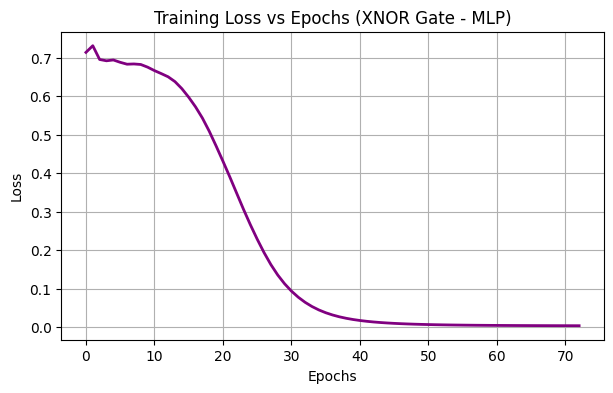

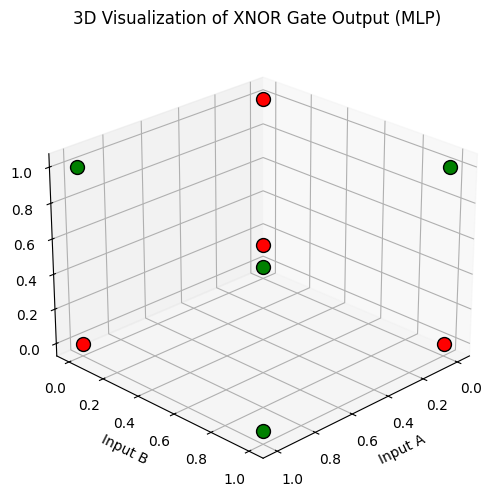

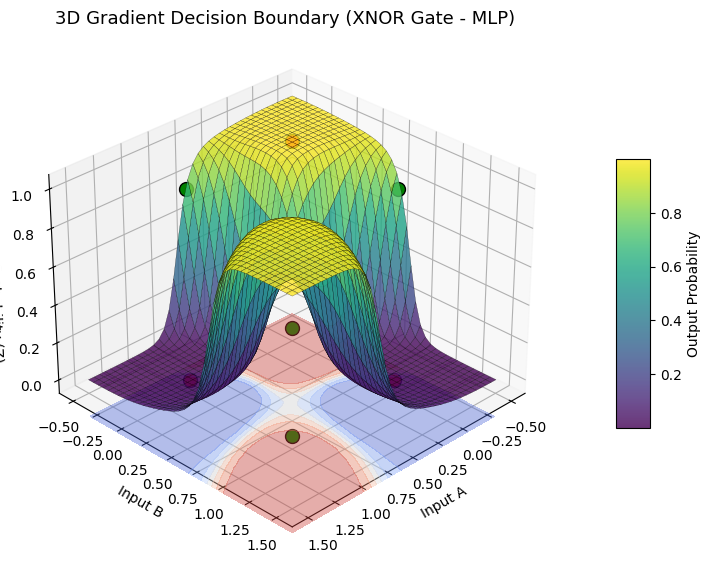

In [1]:
# xnor_gate_mlp.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------
# 1️⃣ Define dataset for 3-input XNOR gate
# --------------------------------------------
# Inputs (A, B, C)
X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

# Output (A XNOR B XNOR C) = 1 when number of 1s is even
y = np.array([1, 0, 0, 1, 0, 1, 1, 0])

# --------------------------------------------
# 2️⃣ Build and train the MLP model
# --------------------------------------------
model = MLPClassifier(hidden_layer_sizes=(6,), activation='tanh',
                      solver='adam', learning_rate_init=0.1,
                      max_iter=1000, random_state=42)

# Train model
model.fit(X, y)

# Loss curve for plotting
loss_curve = model.loss_curve_

# --------------------------------------------
# 3️⃣ Evaluate model performance
# --------------------------------------------
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred)

# --------------------------------------------
# 4️⃣ Print summary results
# --------------------------------------------
print("\n=== XNOR Gate using Multi-Layer Perceptron ===")
print("Hidden Layer Weights:\n", model.coefs_[0])
print("Output Layer Weights:\n", model.coefs_[1])
print("Biases:\n", model.intercepts_)
print("\nPredictions:", y_pred)
print("\nAccuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# --------------------------------------------
# 5️⃣ Plot Loss Curve
# --------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_curve, color='purple', linewidth=2)
plt.title("Training Loss vs Epochs (XNOR Gate - MLP)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --------------------------------------------
# 6️⃣ 3D Visualization of Predictions
# --------------------------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k')

ax.set_title("3D Visualization of XNOR Gate Output (MLP)")
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Input C")
ax.view_init(25, 45)
plt.show()

# --------------------------------------------
# 7️⃣ Enhanced 3D Gradient / Decision Boundary
# --------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot points
for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k', depthshade=True)

# Create a mesh grid
x_range = np.linspace(-0.5, 1.5, 40)
y_range = np.linspace(-0.5, 1.5, 40)
xx, yy = np.meshgrid(x_range, y_range)
zz = np.zeros_like(xx)  # fix C=0 for visualization

# Predict probabilities across the grid
input_grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
Z = model.predict_proba(input_grid)[:, 1]
Z = Z.reshape(xx.shape)

# Plot decision gradient surface
surf = ax.plot_surface(xx, yy, Z, cmap='viridis', alpha=0.8, edgecolor='k', linewidth=0.2)
fig.colorbar(surf, shrink=0.5, aspect=8, pad=0.1, label='Output Probability')

# Add contour projection for clarity
ax.contourf(xx, yy, Z, zdir='z', offset=-0.2, cmap='coolwarm', alpha=0.4)

ax.set_title("3D Gradient Decision Boundary (XNOR Gate - MLP)", fontsize=13)
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Output Probability (Z)")
ax.view_init(30, 45)
plt.show()

In [2]:
import joblib
joblib.dump(model, "xnor_gate_mlp.pkl")

['xnor_gate_mlp.pkl']